# Post-hoc analysis from a saved inversion bundle

An inversion saved with `run_halo.py --save DIR` (or `save_inversion(...)`) can be reloaded and analyzed **without re-reading the Jacobian or re-solving** — aggregation and disaggregation are linear functionals of the posterior, and the bundle stores the factors that reproduce `aᵀx̂` and `aᵀŜa` exactly.

This notebook demonstrates the reader (`load_inversion` → `SavedInversion`) and useful plots:

1. Load + inspect the bundle
2. Posterior scalar fields and their uncertainty
3. Observation diagnostics (obs / background / enhancement / modeled / residual / outliers)
4. Model–data mismatch: normalized residuals, per-flight bias/RMS, along-track autocorrelation
5. The retrieved background offset(s)
6. Buffer region (out-of-core nuisance state): prior vs posterior super-cell fluxes
7. **Post-hoc re-aggregation with uncertainty**: domain total, regional sub-totals, and sector totals with their cross-covariance

Point `BUNDLE_DIR` at one of your real bundles to use real results; otherwise a small synthetic bundle (now including a buffer region) is built so the notebook runs anywhere.

In [4]:
import os, sys, tempfile
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

BAYES_OPT = os.path.dirname(os.path.dirname(os.path.abspath('saved_bundle_analysis.ipynb')))
if BAYES_OPT not in sys.path:
    sys.path.insert(0, BAYES_OPT)
import halo_oe  # noqa: F401

from halo_oe.io_bundle import load_inversion
from halo_oe.flux import cell_areas_m2
from halo_oe.plotting import plot_posterior,plot_residuals,plot_buffer_regions

# Set this to a real bundle directory (from `run_halo.py --save`) to analyze real
# results. Bundles now live under bayes_opt/runs/. If the path does not exist, a
# small synthetic bundle (with a buffer region) is built below.
BUNDLE_DIR_1 = os.environ.get('HALO_BUNDLE', os.path.join(BAYES_OPT, 'runs', 'bg_deg1'))
BUNDLE_DIR_2 = os.environ.get('HALO_BUNDLE', os.path.join(BAYES_OPT, 'runs', 'bg_deg2'))


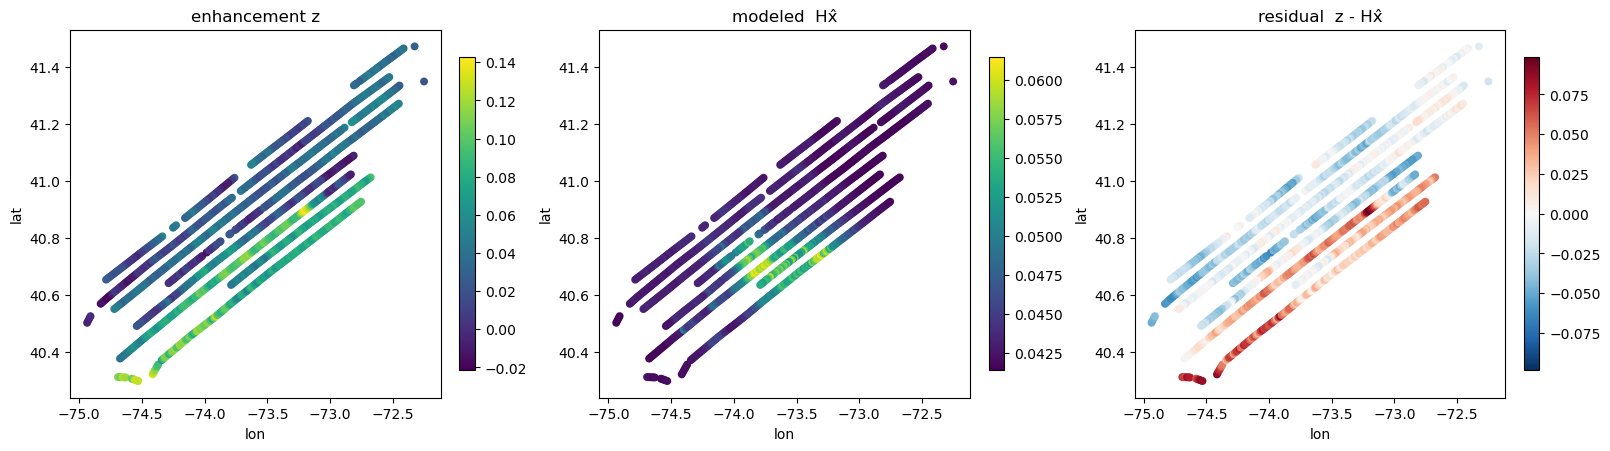

reduced chi-square (saved): 0.520   (~1 = error model consistent)
residual: mean -0.0010  rms 0.0317 ppm  robust sigma(MAD) 0.0309 ppm
  flight 20230726_1     n=1271  bias -0.0010  rms 0.0317 ppm


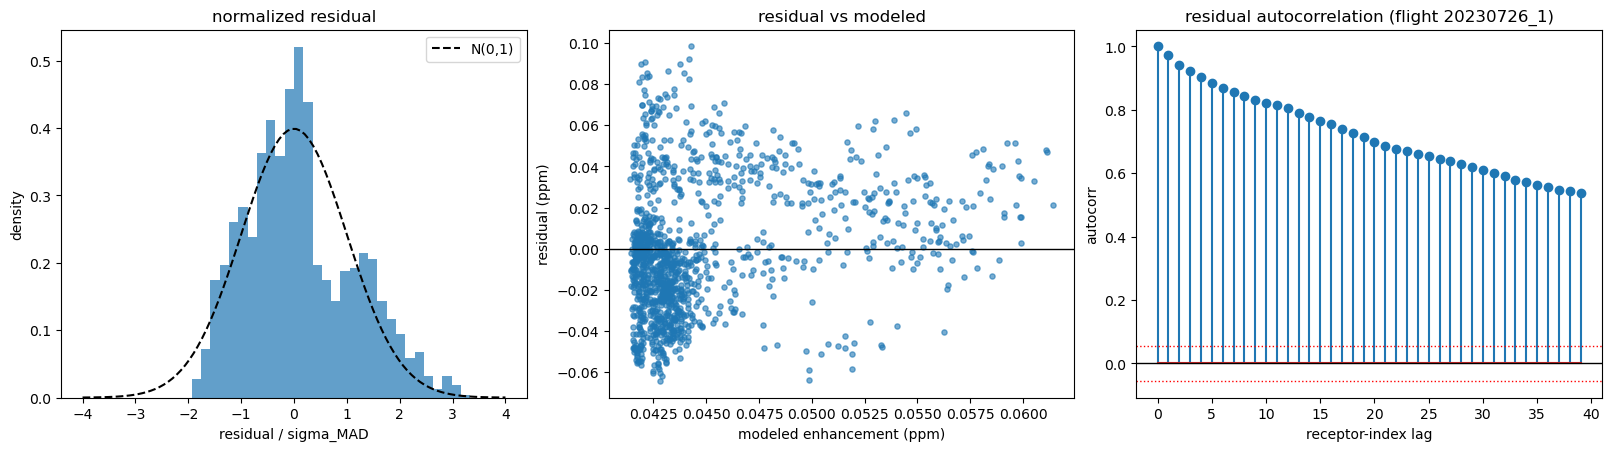

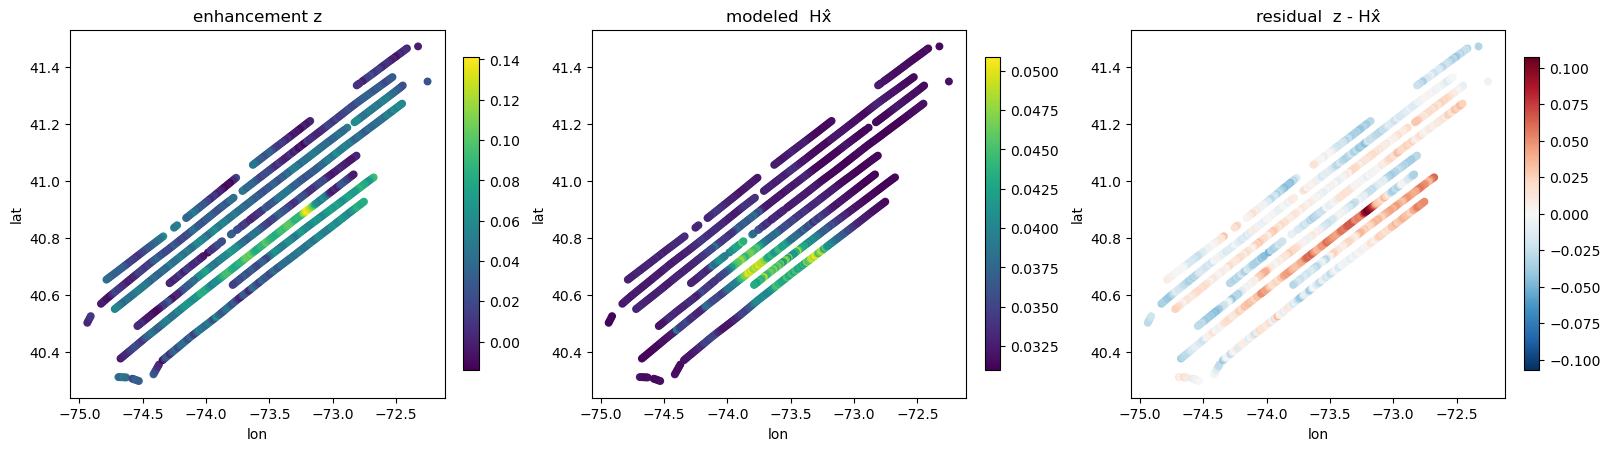

reduced chi-square (saved): 0.375   (~1 = error model consistent)
residual: mean +0.0011  rms 0.0247 ppm  robust sigma(MAD) 0.0249 ppm
  flight 20230726_1     n=1271  bias +0.0011  rms 0.0247 ppm


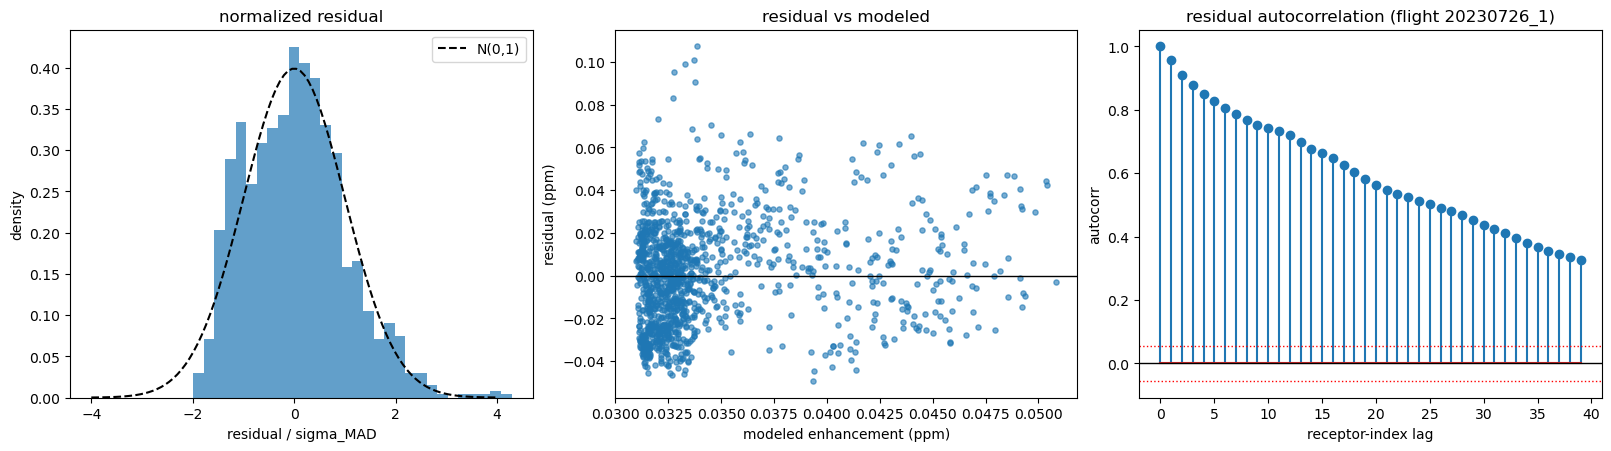

In [5]:
plot_residuals(BUNDLE_DIR_1)
plot_residuals(BUNDLE_DIR_2)

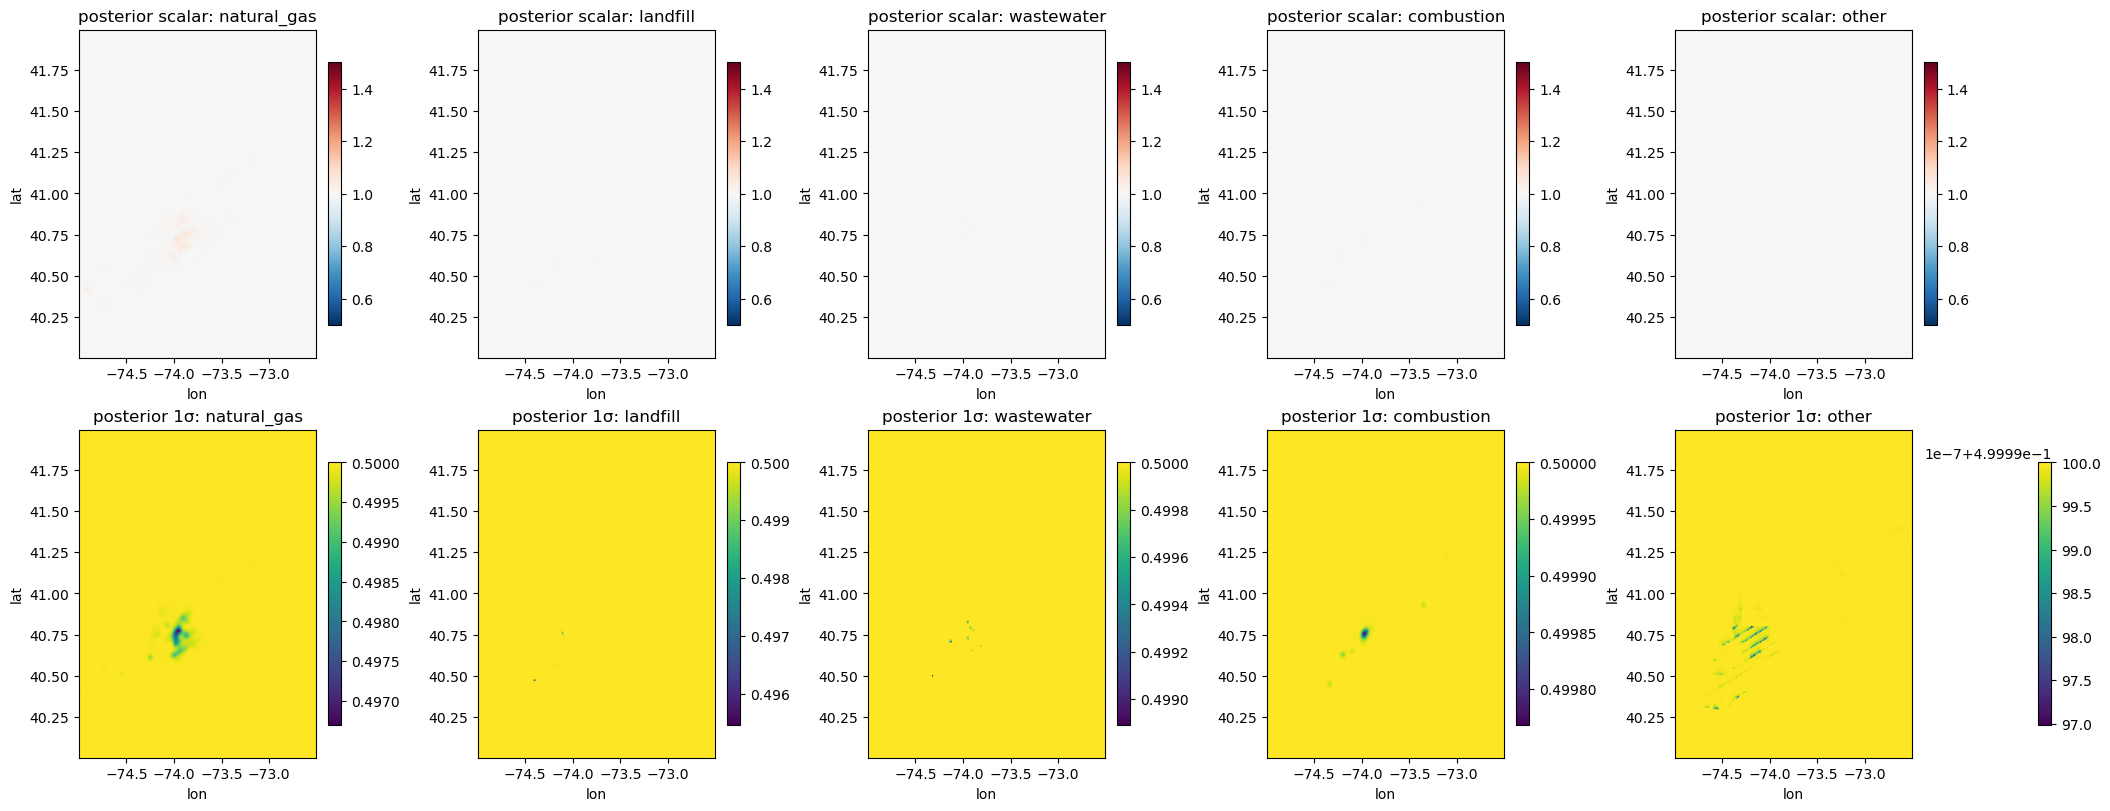

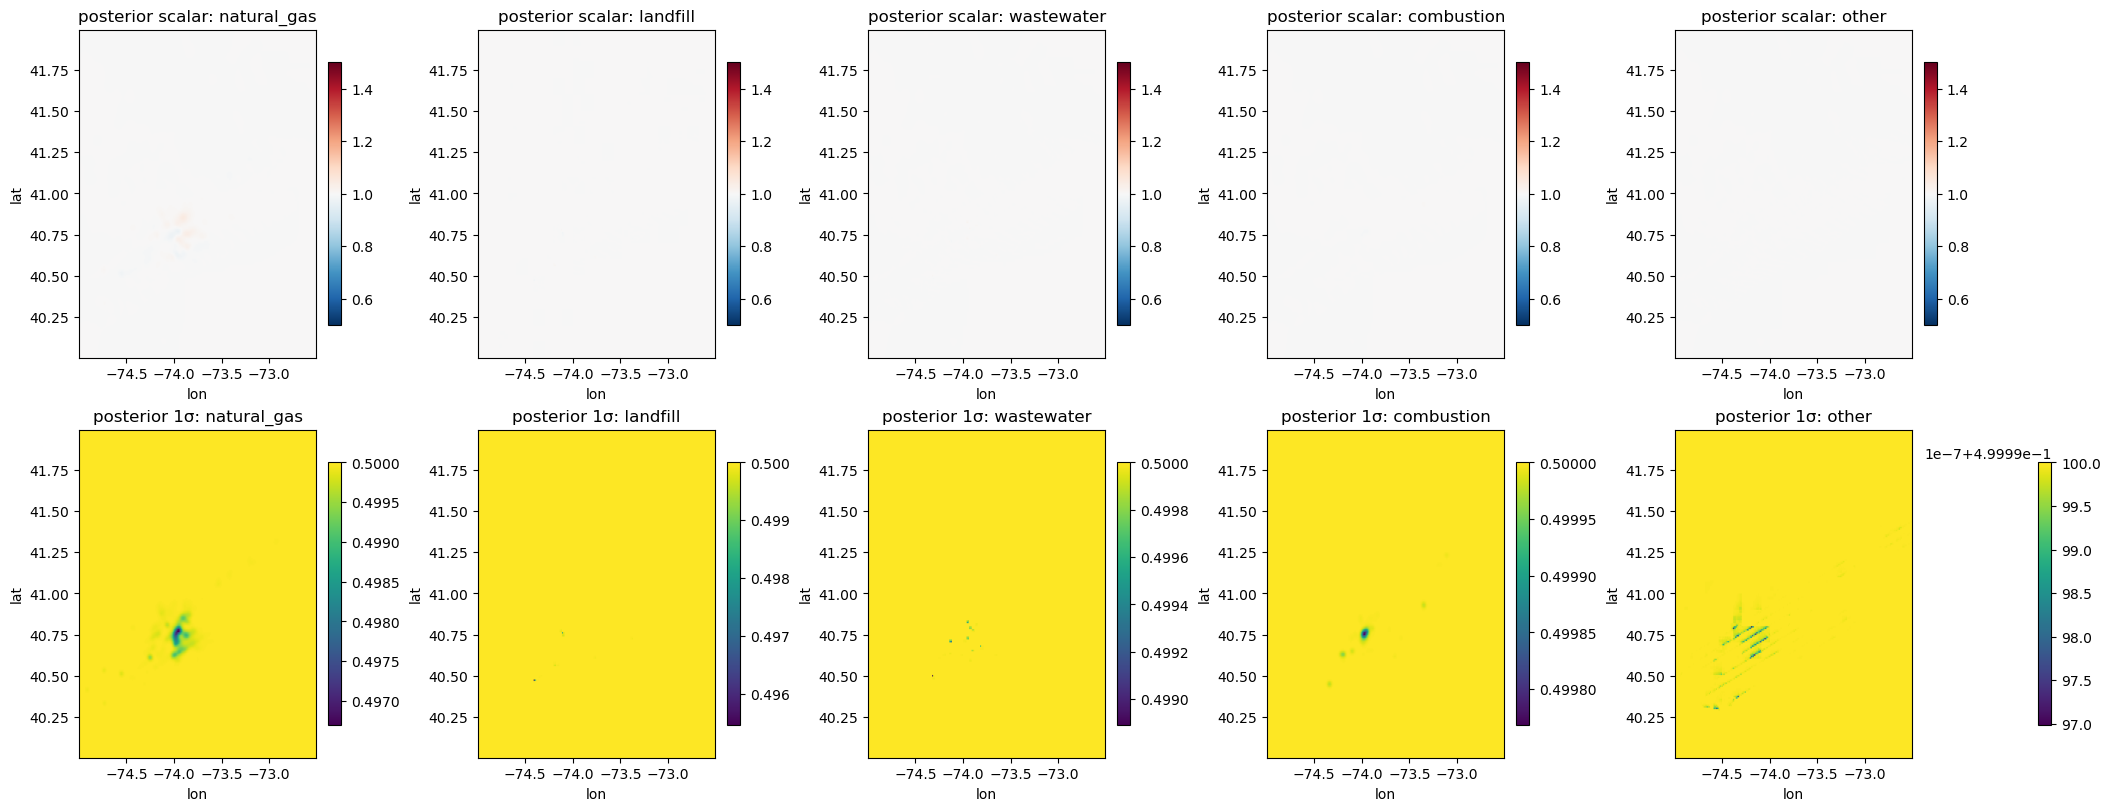

In [6]:
plot_posterior(load_inversion(BUNDLE_DIR_1))
plot_posterior(load_inversion(BUNDLE_DIR_2))

## 5. Retrieved background offset(s)

One optimized offset per flight, on top of the fitted background plane.

In [7]:
if 'bc' in inv.state.names:
    bc = inv.block('bc'); bc_sd = inv.state.unpack(inv.posterior.stddev())['bc']
    for fid, v, s in zip(inv.flight_ids, bc, bc_sd):
        print(f'  background offset [{fid}]: {v:+.4f} +/- {s:.4f} ppm')
else:
    print('no background-offset block in this inversion')

  background offset [20230726_1]: +0.0307 +/- 0.0017 ppm


## Takeaways

Everything above came from the reloaded bundle alone — **no Jacobian, no re-solve**:

- `inv.field(name)` / `inv.block(name)` — posterior fields and block values; `posterior.stddev()` for uncertainty.
- `inv.receptors` — the full observation context (obs, background, enhancement, modeled, flight, outlier flag) for residual and QC analysis.
- `inv.estimate(A)` — the engine for post-hoc work: any linear functional's posterior **mean and full covariance**. Build `A` for a region (tiled), a sector (per category block), or any custom aggregation/disaggregation, and you get the answer with correct uncertainty, including cross-terms.
- `inv.group_fields` — the super-category prior fields, for re-grouping categories or a variance-weighted disaggregation.

Run the expensive inversion once with `--save`; explore the posterior as many ways as you like from the bundle.

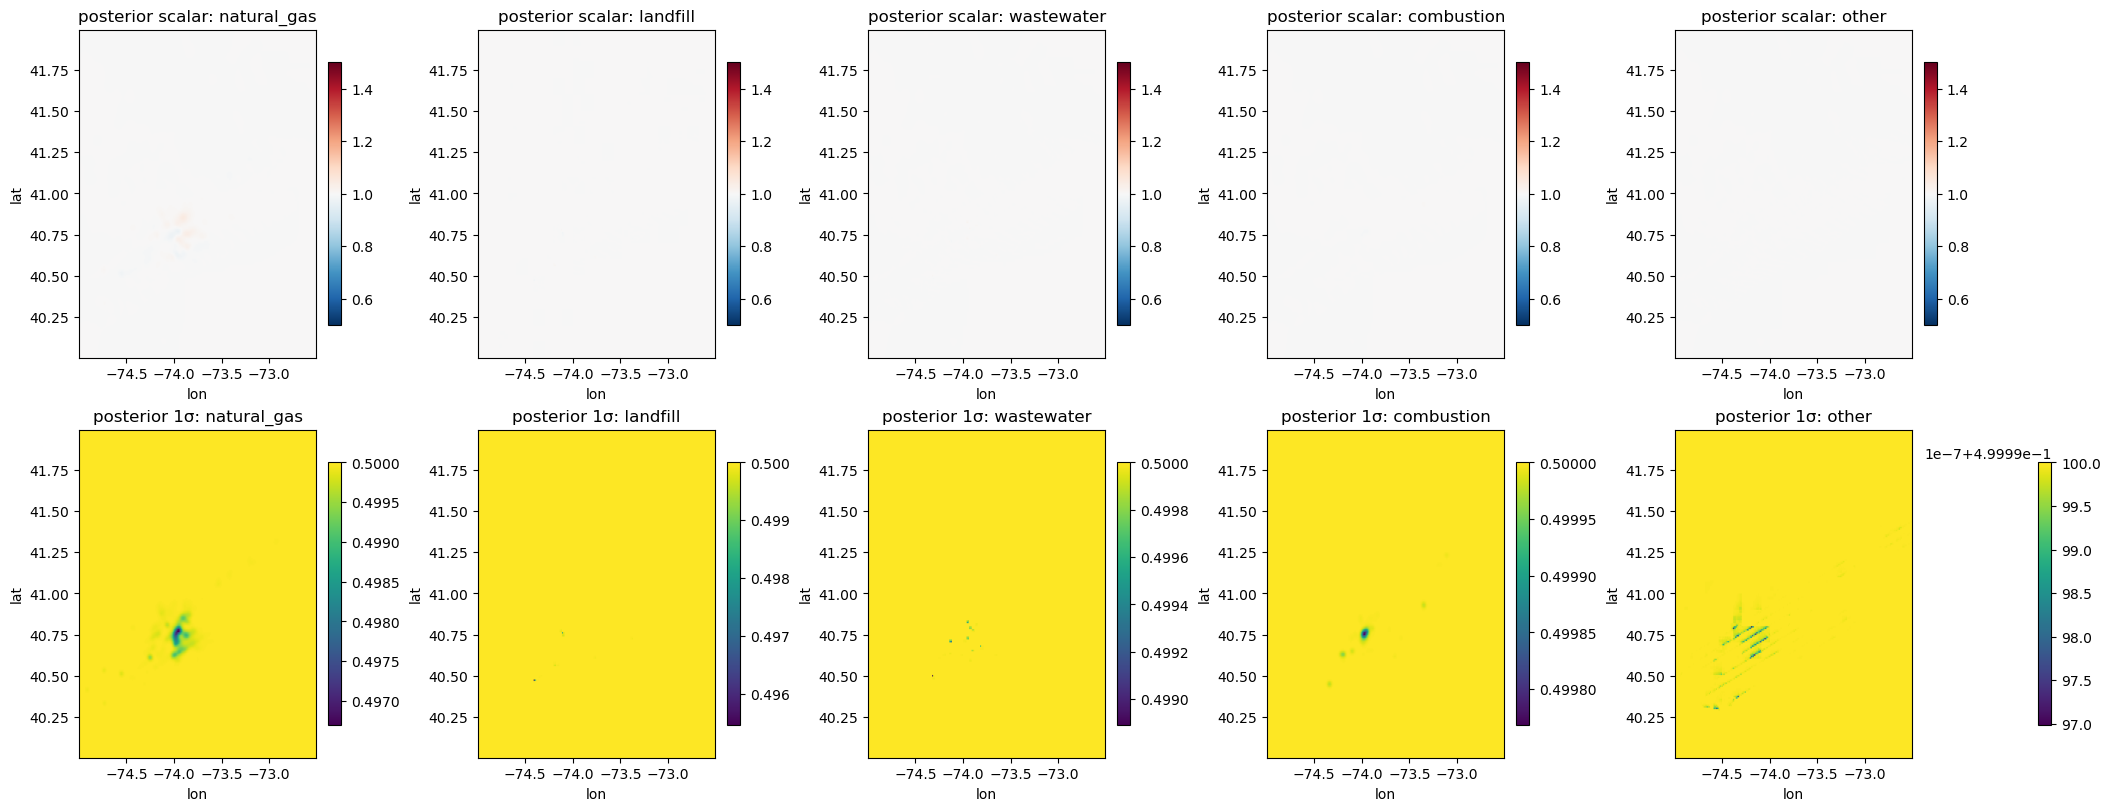

In [1]:
import os, sys, tempfile
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

BAYES_OPT = os.path.dirname(os.path.dirname(os.path.abspath('saved_bundle_analysis.ipynb')))
if BAYES_OPT not in sys.path:
    sys.path.insert(0, BAYES_OPT)
import halo_oe  # noqa: F401

from halo_oe.io_bundle import load_inversion
from halo_oe.flux import cell_areas_m2

# Set this to a real bundle directory (from `run_halo.py --save`) to analyze real
# results. Bundles now live under bayes_opt/runs/. If the path does not exist, a
# small synthetic bundle (with a buffer region) is built below.
BUNDLE_DIR = os.environ.get('HALO_BUNDLE', os.path.join(BAYES_OPT, 'runs', 'bg_deg2'))

from halo_oe.plotting import plot_posterior
BUNDLE_DIR = os.environ.get('HALO_BUNDLE', os.path.join(BAYES_OPT, 'runs', 'bg_deg2'))
plot_posterior(load_inversion(BUNDLE_DIR), out_path=None)